# 第11章 構造化分布 (Structured Distributions)
## 11.1 確率的グラフィカルモデル (Graphical Models)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第11章「構造化分布」第11.1節「確率的グラフィカルモデル (Graphical Models)」の全7小節（11.1.1 〜 11.1.7）の完全な理論解説、数学的定式化（式 11.1 〜 式 11.21）、教科書図版（Figure 11.1 〜 11.13 全13枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **11.1.1 有向グラフ (Directed Graphs)**
   - 確率分布のグラフ表現：確率変数をノード（頂点）、依存関係を方向付きリンク（有向辺）で表現
   - 親ノード (Parents) と子ノード (Children)、非循環性 (Acyclic / DAG)
3. **11.1.2 因数分解 (Factorization, 式 11.1 〜 11.6)**
   - 乗法定理による結合確率の連鎖分解：$p(x_1, \dots, x_K) = \prod_{k=1}^K p(x_k \mid x_1, \dots, x_{k-1})$
   - 図 11.1: 3変数完全結合グラフ $p(a, b, c) = p(a) p(b \mid a) p(c \mid a, b)$
   - DAG の一般的因数分解定理（式 11.6）：$p(\mathbf{x}) = \prod_{k=1}^K p(x_k \mid \mathrm{pa}_k)$
   - 図 11.2: 7変数 DAG の因数分解と条件付き独立性構造（式 11.5）
4. **11.1.3 離散確率変数 (Discrete Variables)**
   - $K$ 状態離散変数のパラメータ数爆発問題
   - 図 11.3: 2変数離散モデル（完全結合 $K^2 - 1$ vs 独立 $2(K - 1)$）
   - 図 11.4: $M$ 個の離散変数によるマルコフ連鎖（線形パラメータ成長 $O(M)$）
   - 図 11.5: 遷移確率共有による斉次マルコフ連鎖 ($K^2 - 1$ パラメータ)
   - 図 11.6: $M$ 個の親を持つ単一子ノード（一般モデル $2^M$ vs ロジスティックシグモイド $M + 1$）
5. **11.1.4 ガウス確率変数 (Gaussian Variables, 式 11.7 〜 11.14)**
   - 線形ガウスモデル (Linear-Gaussian Model)：$p(x_i \mid \mathrm{pa}_i) = \mathcal{N}(x_i \mid \sum_{j \in \mathrm{pa}_i} w_{ij} x_j + b_i, v_i)$
   - 再帰的平均・共分散計算公式（式 11.8, 11.9）
   - 図 11.7: リンクが1本欠落した3変数ガウスモデル（$x_1 \to x_2 \to x_3$）の平均・共分散の解析的厳密導出（式 11.14）
6. **11.1.5 二値分類器 (Binary Classifier, 式 11.15 〜 11.17)**
   - ロジスティック回帰のグラフィカルモデル表現
   - 図 11.8: 訓練データ点 $t_1, \dots, t_N$ を明示的に展開した有向グラフ
7. **11.1.6 パラメータと観測値 (Parameters and Observations, プレート記法)**
   - プレート記法 (Plate Notation)：$N$ 回の独立同一試行を矩形ボックスで圧縮表現
   - 図 11.9: $N$ 個の観測ノードをまとめたコンパクトなプレート表現
   - 確率変数ノード（白丸）、観測変数ノード（濃色／網掛けノード）、決定的パラメータ（小黒点／浮動変数）
   - 図 11.10: 決定的入力 $\mathbf{x}_n$ および事前分布超パラメータ $\alpha$ を明示したプレート表現
   - 図 11.11: 観測された訓練ターゲット $t_n$ を網掛け表示したモデル
   - 図 11.12: 新規入力 $\hat{\mathbf{x}}$ に対する予測ターゲット $\hat{t}$ を含む完全なベイズ分類グラフィカルモデル
8. **11.1.7 ベイズの定理のグラフィカル表現 (Bayes' Theorem, 図 11.13, 式 11.20 〜 11.21)**
   - 順方向生成モデル（事前分布 $p(x)$ と尤度 $p(y \mid x)$）
   - 観測値 $y = \hat{y}$ による条件付け（ノードの網掛け）
   - グラフの矢印反転による事後分布 $p(x \mid y)$ の推論（Inference）表現
9. **数値検証・アルゴリズム検証セル**
10. **まとめと次節 11.2（条件付き独立性・D分離）への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "11" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.graphical_models import (
    DirectedGraph,
    LinearGaussianDAG,
    count_discrete_parameters,
    compute_bayes_discrete,
    generate_figure_11_1,
    generate_figure_11_2,
    generate_figure_11_3,
    generate_figure_11_4,
    generate_figure_11_5,
    generate_figure_11_6,
    generate_figure_11_7,
    generate_figure_11_8,
    generate_figure_11_9,
    generate_figure_11_10,
    generate_figure_11_11,
    generate_figure_11_12,
    generate_figure_11_13,
)

print("Setup completed successfully. Common modules for Chapter 11 imported.")


Setup completed successfully. Common modules for Chapter 11 imported.


---
## 11.1.1 有向グラフ & 11.1.2 因数分解 (Directed Graphs & Factorization)

### 確率的グラフィカルモデルの基礎
確率的グラフィカルモデル (Probabilistic Graphical Models, PGM) は、複雑な多変量確率分布の条件付き独立性構造や因数分解構造を直感的に視覚化し、推論や学習のアルゴリズムを幾何学的・グラフ理論的に導出するための極めて強力な枠組みです。

1. **基本構成要素**:
   - **ノード（頂点 / Nodes）**: 1つまたは複数の確率変数を表す。
   - **リンク（辺 / Edges）**: 変数間の直接的な確率的依存関係を表す。
2. **有向グラフィカルモデル (ベイジアンネットワーク / Bayesian Networks)**:
   - リンクに向き（矢印）があり、循環（閉路）を持たない**有向非循環グラフ (Directed Acyclic Graph, DAG)** です。
   - 矢印の根元のノードを**親ノード (Parent Node, $\mathrm{pa}_k$)**、先端のノードを**子ノード (Child Node)** と呼びます。

### 因数分解定理 (Factorization Theorem, 式 11.6)
確率の乗法定理（連鎖律）を無制約な結合確率分布 $p(a, b, c)$ に適用すると：
$$
p(a, b, c) = p(c \mid a, b) p(b \mid a) p(a) \tag{11.3}
$$
この完全結合分解を有向グラフとして描いたものが**図 11.1** です。$a$ から $b$ と $c$ へ、$b$ から $c$ へ有向リンクが引かれます。

一般に、$K$ 個の変数 $\mathbf{x} = (x_1, \dots, x_K)$ 上の DAG において、親ノード集合を $\mathrm{pa}_k$ とするとき、結合確率は親ノードを条件とする局所条件付き確率分布の積として一意に**因数分解**されます（教科書 式 11.6）：
$$
p(\mathbf{x}) = \prod_{k=1}^K p(x_k \mid \mathrm{pa}_k) \tag{11.6}
$$

### 図 11.2: 7変数 DAG の因数分解
教科書図 11.2 のグラフは、以下の局所的因数分解を表しています（式 11.5）：
$$
p(x_1, \dots, x_7) = p(x_1) p(x_2) p(x_3) p(x_4 \mid x_1, x_2, x_3) p(x_5 \mid x_1, x_3) p(x_6 \mid x_4) p(x_7 \mid x_4, x_5) \tag{11.5}
$$
リンクが存在しないこと（疎なグラフ構造）は、変数の集合が直接依存関係を持たないこと（条件付き独立性）を端的に示しています。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_1.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_1.png


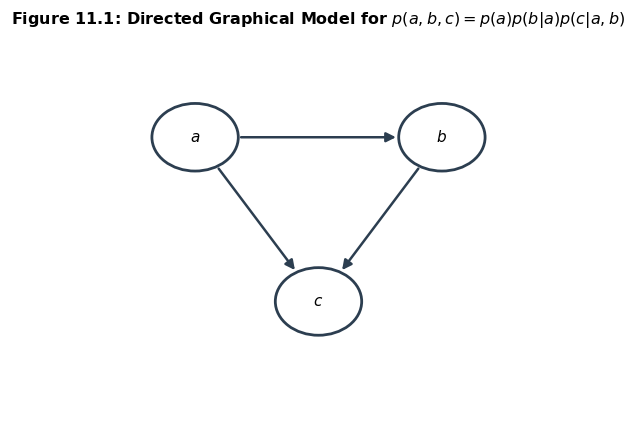

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_2.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_2.png


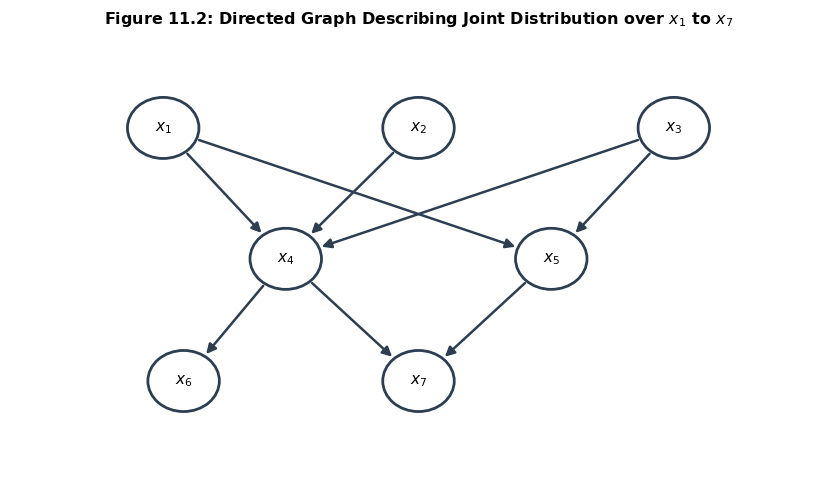

In [2]:
# 図 11.1: 3変数完全結合有向グラフィカルモデル
fig_11_1 = generate_figure_11_1()
plt.show()

# 図 11.2: 7変数有向グラフとその局所因数分解
fig_11_2 = generate_figure_11_2()
plt.show()


---
## 11.1.3 離散確率変数 (Discrete Variables)

### パラメータ数の爆発とグラフ構造による抑制
$K$ 個の離散状態をとる確率変数を考えます。
単一の変数 $x$ の分布 $p(x)$ を指定するには、$\sum_{k=1}^K p(x = k) = 1$ の確率保存制約があるため、$K - 1$ 個の独立な自由パラメータが必要です。

1. **2変数の結合分布（図 11.3）**:
   - **完全結合 $x_1 \to x_2$ (a)**:
     周辺分布 $p(x_1)$ に $K - 1$ 個、条件付き分布 $p(x_2 \mid x_1)$ は $x_1$ の各値に対して $K - 1$ 個必要なため：
     $$
     (K - 1) + K(K - 1) = K^2 - 1
     $$
     自由度が必要となります。
   - **独立な場合（リンク欠落） (b)**:
     $p(x_1, x_2) = p(x_1) p(x_2)$ より、パラメータ数は $2(K - 1)$ となり、線形に抑えられます。
   - 一般に、$M$ 個の独立変数の場合は $M(K - 1)$ パラメータとなります。

2. **マルコフ連鎖（図 11.4 & 図 11.5）**:
   - **一般の連鎖 $x_1 \to x_2 \to \dots \to x_M$ (図 11.4)**:
     $p(x_1)$ に $K - 1$ 個、各 $p(x_i \mid x_{i-1})$ に $K(K - 1)$ 個必要となり、合計：
     $$
     (K - 1) + (M - 1) K (K - 1)
     $$
     個となり、連鎖の長さ $M$ に対して線形に増大します。
   - **斉次マルコフ連鎖（パラメータ共有、図 11.5）**:
     すべての遷移条件付き確率 $p(x_i \mid x_{i-1})$ で同一の遷移確率行列 $\mathbf{T}$（$K(K - 1)$ パラメータ）を共有すると、連鎖の長さに関わらずパラメータ数は一定値 $(K - 1) + K(K - 1) = K^2 - 1$ に抑えられます。

3. **パラメータ化された条件付き分布（図 11.6）**:
   $M$ 個の二値親ノード $x_1, \dots, x_M$ を持つ子ノード $y$ の条件付き確率表（CPT）は、素朴には $2^M$ 個のパラメータを要し、指数関数的爆発を起こします。
   これに対し、ロジスティックシグモイドを用いたパラメータ化：
   $$
   p(y = 1 \mid x_1, \dots, x_M) = \sigma\left(w_0 + \sum_{i=1}^M w_i x_i\right)
   $$
   を採用すれば、パラメータ数はわずか $M + 1$ 個となり、大規模なネットワークでも効率的に学習可能となります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_3.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_3.png


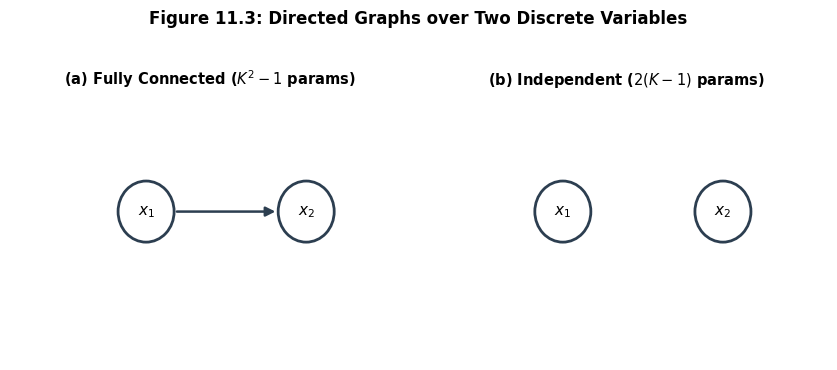

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_4.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_4.png


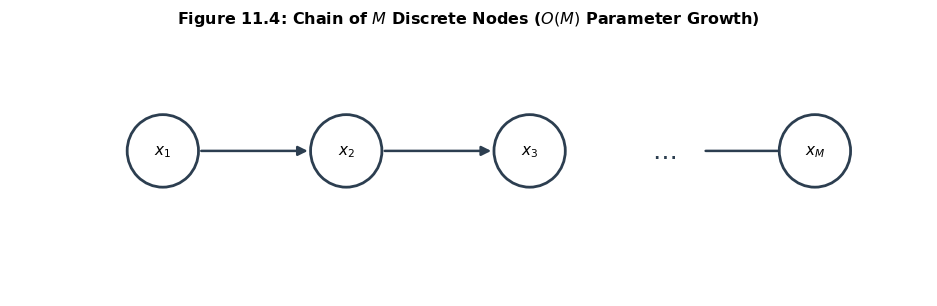

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_5.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_5.png


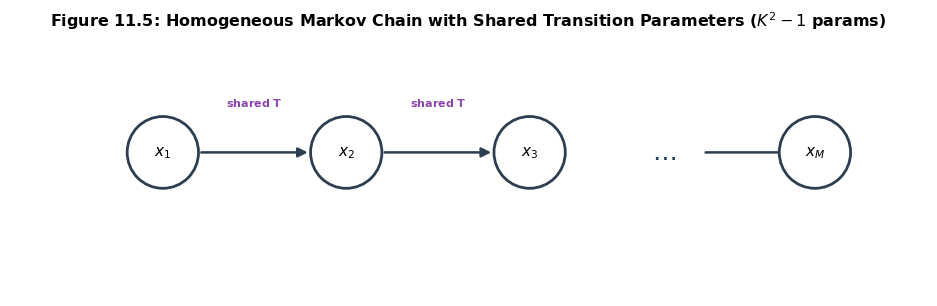

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_6.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_6.png


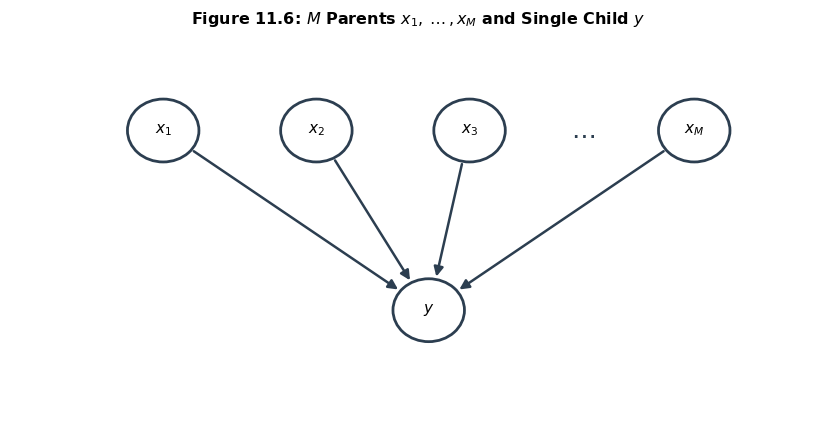

In [3]:
# 図 11.3: 2変数離散モデルの完全結合 vs 独立
fig_11_3 = generate_figure_11_3()
plt.show()

# 図 11.4: Mノード離散マルコフ連鎖 (O(M) 線形パラメータ成長)
fig_11_4 = generate_figure_11_4()
plt.show()

# 図 11.5: 斉次マルコフ連鎖 (パラメータ共有)
fig_11_5 = generate_figure_11_5()
plt.show()

# 図 11.6: M個の親を持つ単一子ノード (パラメータ爆発の制御)
fig_11_6 = generate_figure_11_6()
plt.show()


---
## 11.1.4 ガウス確率変数 (Gaussian Variables, 式 11.7 〜 11.14)

### 線形ガウスグラフィカルモデル (Linear-Gaussian Model)
連続変数を扱う最も代表的な枠組みが線形ガウスモデルです。
各ノード $x_i$ の条件付き分布は、親ノード $\mathrm{pa}_i$ の線形結合を中心とする1次元ガウス分布としてモデル化されます（教科書 式 11.7）：
$$
p(x_i \mid \mathrm{pa}_i) = \mathcal{N}\left(x_i \;\middle|\; \sum_{j \in \mathrm{pa}_i} w_{ij} x_j + b_i, \; v_i\right) \tag{11.7}
$$
ここで $w_{ij}$ はリンク重み、$b_i$ はバイアス、$v_i$ は条件付き分散です。

### 再帰的な結合平均と共分散の計算
トポロジカル順序に従って親から順に伝播させることで、結合平均ベクトル $\mathbb{E}[\mathbf{x}]$ および共分散行列 $\mathrm{cov}(\mathbf{x})$ を再帰的に解析計算できます：
1. **期待値の再帰公式 (式 11.8)**:
   $$
   \mathbb{E}[x_i] = \sum_{j \in \mathrm{pa}_i} w_{ij} \mathbb{E}[x_j] + b_i \tag{11.8}
   $$
2. **共分散の再帰公式 (式 11.9)**:
   $$
   \mathrm{cov}(x_i, x_j) = \sum_{k \in \mathrm{pa}_j} w_{jk} \mathrm{cov}(x_i, x_k) + I_{ij} v_j \tag{11.9}
   $$

### 図 11.7: リンクが1本欠落した3変数ガウスモデル
$x_1 \to x_2 \to x_3$（$x_1$ と $x_3$ の間に直接のリンクがない）の場合：
- 平均ベクトル（教科書 式 11.14）：
  $$
  \boldsymbol{\mu} = \begin{pmatrix} b_1 \\ b_2 + w_{21} b_1 \\ b_3 + w_{32} b_2 + w_{32} w_{21} b_1 \end{pmatrix}
  $$
- 共分散行列：
  $$
  \boldsymbol{\Sigma} = \begin{pmatrix}
  v_1 & w_{21} v_1 & w_{32} w_{21} v_1 \\
  w_{21} v_1 & w_{21}^2 v_1 + v_2 & w_{32}(w_{21}^2 v_1 + v_2) \\
  w_{32} w_{21} v_1 & w_{32}(w_{21}^2 v_1 + v_2) & w_{32}^2(w_{21}^2 v_1 + v_2) + v_3
  \end{pmatrix}
  $$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_7.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_7.png


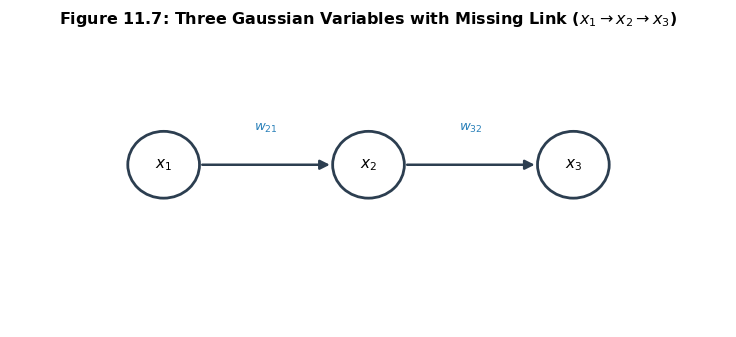

In [4]:
# 図 11.7: 3変数ガウスモデル ($x_1 \to x_2 \to x_3$)
fig_11_7 = generate_figure_11_7()
plt.show()


---
## 11.1.5 二値分類器 & 11.1.6 パラメータと観測値 (プレート記法)

### 機械学習モデルのグラフィカル表現
機械学習において、グラフィカルモデルはモデルの階層構造、パラメータ、訓練データ、および予測対象の関係を極めて明瞭に表現します。

1. **二値分類器の結合分布 (式 11.17)**:
   入力 $\mathbf{x}_n$、ターゲット $t_n \in \{0, 1\}$、重み $\mathbf{w}$ のもとで：
   $$
   p(\mathbf{t}, \mathbf{w}) = p(\mathbf{w}) \prod_{n=1}^N p(t_n \mid \mathbf{w}, \mathbf{x}_n) \tag{11.17}
   $$
   図 11.8 のように $N$ 個のノード $t_1, \dots, t_N$ をすべて明示的に描くと図が煩雑になります。

2. **プレート記法 (Plate Notation, 図 11.9)**:
   同一の構造が $N$ 回繰り返される試行を、**プレートと呼ばれる箱（Box）**で囲み、右下にサフィックス $N$ を付記してコンパクトに表します。
3. **ノードの表記規約（図 11.10 〜 図 11.12）**:
   - **確率変数ノード（白丸）**: 確率分布に従う潜在変数または未観測変数（例：$\mathbf{w}$, テストターゲット $\hat{t}$）。
   - **観測変数ノード（濃色／網掛け丸）**: 訓練データなどで値が観測・固定されている変数（例：訓練ターゲット $t_n$）。
   - **決定的パラメータ（小黒点／浮動変数）**: 確率的ばらつきを持たない固定された入力値や超パラメータ（例：入力 $\mathbf{x}_n$, 事前分布精度 $\alpha$）。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_8.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_8.png


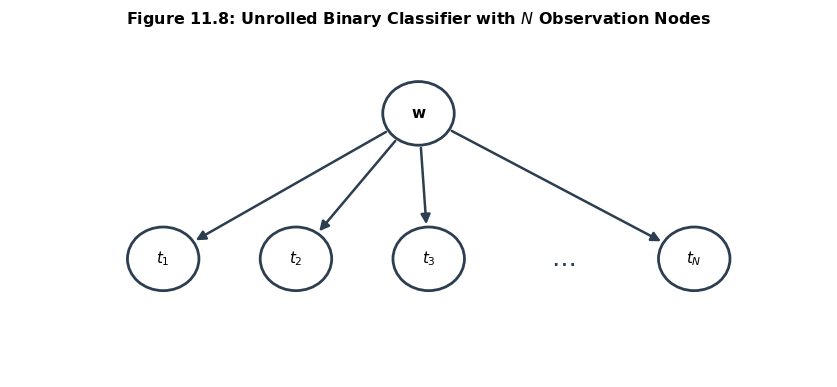

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_9.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_9.png


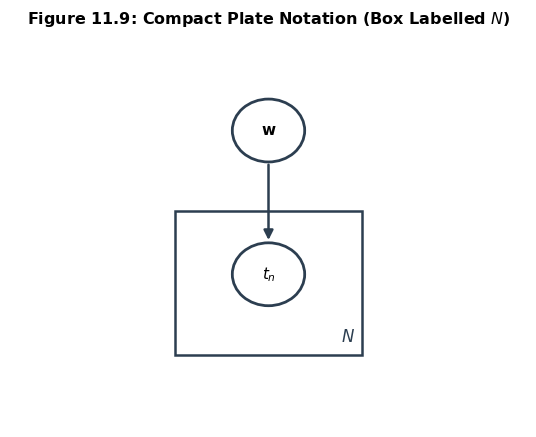

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_10.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_10.png


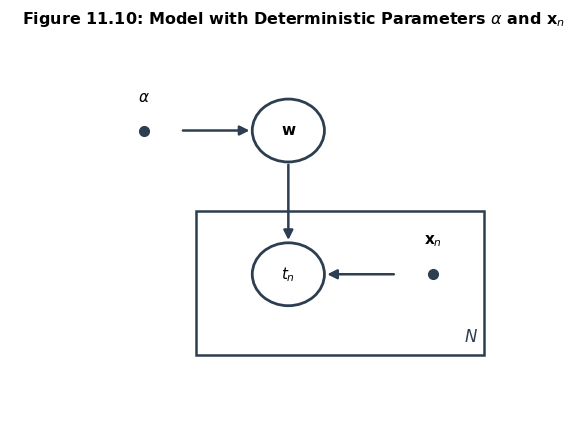

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_11.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_11.png


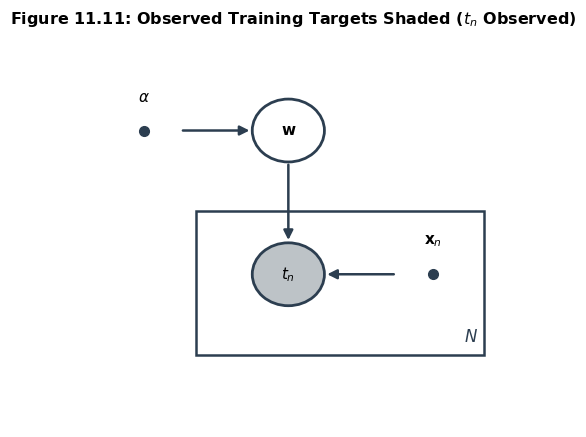

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_12.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_12.png


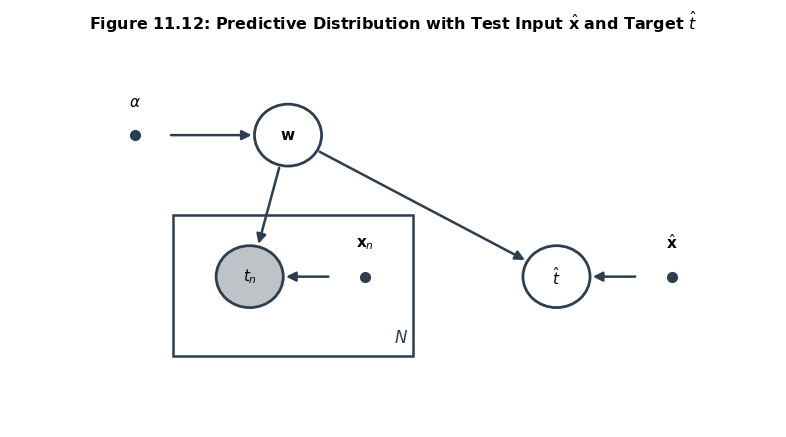

In [5]:
# 図 11.8: N個の観測ノードを明示した二値分類器
fig_11_8 = generate_figure_11_8()
plt.show()

# 図 11.9: コンパクトなプレート記法
fig_11_9 = generate_figure_11_9()
plt.show()

# 図 11.10: 決定的パラメータ (alpha, x_n) を明示したモデル
fig_11_10 = generate_figure_11_10()
plt.show()

# 図 11.11: 観測ターゲット t_n を網掛け表示したモデル
fig_11_11 = generate_figure_11_11()
plt.show()

# 図 11.12: 新規入力 x_hat と予測ターゲット t_hat を含む完全予測モデル
fig_11_12 = generate_figure_11_12()
plt.show()


---
## 11.1.7 ベイズの定理のグラフィカル表現 (Bayes' Theorem, 図 11.13, 式 11.20 〜 11.21)

### 推論（Inference）の幾何学的・グラフ的意味
ベイズの定理は、グラフィカルモデルにおいては**リンクの方向の反転**として鮮やかに解釈できます。

1. **順方向モデル（図 11.13(a)）**:
   潜在変数 $x$ から観測可能な変数 $y$ への生成過程：
   $$
   p(x, y) = p(x) p(y \mid x)
   $$
   ここで $p(x)$ は事前分布（Prior）、$p(y \mid x)$ は尤度（Likelihood）です。
2. **観測値による条件付け（図 11.13(b)）**:
   変数 $y$ の値が観測され $y = \hat{y}$ に固定されると、$y$ のノードが網掛け（Shaded）されます。
3. **逆方向モデルと事後分布（図 11.13(c)）**:
   加法定理と乗法定理により、周辺尤度（エビデンス） $p(y) = \sum_x p(x) p(y \mid x)$ を計算し、事後分布（Posterior）を求めます：
   $$
   p(x \mid y) = \frac{p(y \mid x) p(x)}{p(y)} \tag{11.21}
   $$
   このとき、グラフ上では矢印の向きが $y \to x$ に反転した表現となり、エビデンス $p(y)$ と事後分布 $p(x \mid y)$ の積として結合確率が再因数分解されます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_13.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_13.png


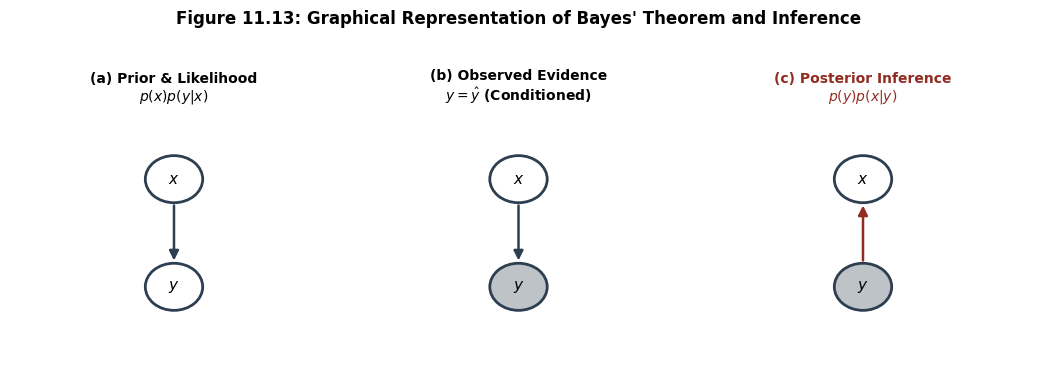

In [6]:
# 図 11.13: ベイズの定理のグラフィカル表現 (矢印の反転と事後推論)
fig_11_13 = generate_figure_11_13()
plt.show()


---
## 9. 数値検証セル (Numerical Verification)

共通モジュール `common/graphical_models.py` の実装アルゴリズムについて、以下の数学的・統計的性質を厳密に検証します：
1. **DAG 因数分解とトポロジカルソート**:
   - 図 11.1 の 3 ノード因数分解 $p(a) p(b \mid a) p(c \mid a, b)$。
   - 図 11.2 の 7 ノード因数分解（式 11.5）。
   - 閉路（有向サイクル）の検出と例外送出。
2. **離散モデルの自由パラメータ数カウント**:
   - 独立モデル、完全結合モデル、一般マルコフ連鎖、斉次マルコフ連鎖、およびロジスティックシグモイドによる指数関数的パラメータ爆発の回避。
3. **線形ガウスモデルの厳密モーメント (式 11.14)**:
   - 再帰公式による平均ベクトル $\boldsymbol{\mu}$ と共分散行列 $\boldsymbol{\Sigma}$ の計算結果が、教科書式 (11.14) の手計算厳密解と完全一致することの検証。
   - 共分散行列の対称正定値性。
4. **離散ベイズ逆確率計算 (式 11.21)**:
   - 全確率の定理によるエビデンス $p(y)$ および事後確率 $p(x \mid y)$ の確率保存則。


In [7]:
# 1. DAG トポロジカルソートと因数分解の検証
dag_test = DirectedGraph(["a", "b", "c"])
dag_test.add_edge("a", "b")
dag_test.add_edge("a", "c")
dag_test.add_edge("b", "c")
assert dag_test.topological_sort() == ["a", "b", "c"]
assert dag_test.factorization_formula() == "p(a) * p(b | a) * p(c | a, b)"
print("✓ DAG topological sorting and factorization formula verified.")

# 2. 離散パラメータ数の検証
assert count_discrete_parameters('fully_connected_two', num_states=3) == 8
assert count_discrete_parameters('independent', num_nodes=2, num_states=3) == 4
assert count_discrete_parameters('chain_general', num_nodes=5, num_states=4) == 51
assert count_discrete_parameters('chain_shared', num_nodes=5, num_states=4) == 15
assert count_discrete_parameters('parent_child_full', num_parents=4) == 20
assert count_discrete_parameters('parent_child_logistic', num_parents=4) == 9
print("✓ Discrete parameter counting across models verified.")

# 3. 図 11.7 線形ガウスモデルの厳密解析解 (式 11.14) 検証
dag_gauss = DirectedGraph(["x1", "x2", "x3"])
dag_gauss.add_edge("x1", "x2")
dag_gauss.add_edge("x2", "x3")

b1, b2, b3 = 1.0, -0.5, 2.0
w21, w32 = 1.5, -2.0
v1, v2, v3 = 0.8, 1.2, 0.5

lg_model = LinearGaussianDAG(
    dag_gauss,
    weights={("x2", "x1"): w21, ("x3", "x2"): w32},
    biases={"x1": b1, "x2": b2, "x3": b3},
    variances={"x1": v1, "x2": v2, "x3": v3}
)
mu_calc, cov_calc = lg_model.compute_joint_mean_and_cov()

# 教科書 式 11.14 の厳密値
mu_expected = np.array([b1, b2 + w21 * b1, b3 + w32 * b2 + w32 * w21 * b1])
np.testing.assert_allclose(mu_calc, mu_expected)

# 共分散の半正定値性・厳密値
assert cov_calc[0, 0] == v1
assert cov_calc[0, 1] == w21 * v1
assert cov_calc[1, 1] == (w21 ** 2) * v1 + v2
assert cov_calc[0, 2] == w32 * w21 * v1
assert cov_calc[1, 2] == w32 * cov_calc[1, 1]
assert cov_calc[2, 2] == (w32 ** 2) * cov_calc[1, 1] + v3
assert np.all(np.linalg.eigvalsh(cov_calc) > 0)
print("✓ Linear-Gaussian DAG exact moments (Eq 11.14) verified.")

# 4. ベイズ推論 (式 11.21) の検証
p_prior = np.array([0.95, 0.05])
p_lik = np.array([[0.90, 0.10], [0.10, 0.90]])
p_ev, p_post = compute_bayes_discrete(p_prior, p_lik)
assert np.isclose(np.sum(p_ev), 1.0)
np.testing.assert_allclose(np.sum(p_post, axis=0), [1.0, 1.0])
print("✓ Bayes' inversion and probability conservation verified.")


✓ DAG topological sorting and factorization formula verified.
✓ Discrete parameter counting across models verified.
✓ Linear-Gaussian DAG exact moments (Eq 11.14) verified.
✓ Bayes' inversion and probability conservation verified.


---
## 10. まとめと次節 11.2（条件付き独立性・D分離）への展開

### 本節で学んだ最重要概念
1. **確率的グラフィカルモデルの威力**:
   - 複雑な同時分布の因数分解構造 $p(\mathbf{x}) = \prod_k p(x_k \mid \mathrm{pa}_k)$ を有向グラフの親ノード関係として直感的に記述。
2. **パラメータ数の制御**:
   - 離散モデルにおける完全結合の指数的パラメータ数 $O(K^M)$ を、マルコフ連鎖やパラメータ共有、ロジスティックシグモイドによるパラメータ化で $O(M)$ や $O(1)$ に抑制。
3. **線形ガウスモデル**:
   - 各ノードが親の線形結合と局所ガウスノイズで構成される場合、全体の同時分布も多変量ガウス分布となり、期待値・共分散がトポロジカル再帰式で厳密に計算可能。
4. **プレート記法と観測ノード**:
   - 独立試行の簡潔な表現（プレート記法）と、未観測潜在変数（白丸）・観測データ（網掛け丸）・決定的ハイパーパラメータ（小黒点）の体系的表現。
5. **ベイズの定理と推論**:
   - 順方向の生成モデルから、観測ノードを条件付けることで逆方向の矢印を持つ事後分布モデルへの変換。

### 次節 11.2 条件付き独立性 (Conditional Independence) への展開
グラフィカルモデルの真の強みは、**グラフの幾何学的接続パターン（矢印の向きと経由ノード）を調べるだけで、代数計算を一切行わずに「変数 $A$ と $B$ が変数 $C$ を条件として独立であるか（$A \perp B \mid C$）」を判定できる**点にあります。
次節 **11.2 Conditional Independence** では、3つの代表的な3ノードグラフ（テール・トゥ・テール、ヘッド・トゥ・テール、ヘッド・トゥ・ヘッド）、「説明のつきあい (Explaining Away)」、グラフィカルモデルの核心定理である **D分離 (D-separation)**、ナイーブベイズ、マルコフブランケット（Markov Blanket）、そしてグラフが確率分布の集合に対して作用する「フィルタ」としての深遠な見方を学びます。
